# Notebook 02 · Spatial Transferability — Hanoi & HCMC
## Apply Milan-trained model to Vietnam + spatially stratified local retrain

**Changes from original:**
- Train/test split now uses **spatial 1km blocks** (not random stratified) with 250m buffer
- Local retrain (Scenario B) uses **spatial block CV** for hyperparameter tuning across 500m/1km/2km blocks
- Best CV block size selected per city based on lowest spatial CV RMSE
- Figure 0 added: spatial split visualisation per city
- Test points overlaid on raster maps

**Scenarios (unchanged):**
1. Scenario A — Milan model transfer: apply Milan RF directly to Vietnam AEF
2. Scenario B — Local retrain: train fresh RF on spatial training set with spatial CV tuning

---
## Cell 1 · Imports & configuration

In [2]:
#ee.Authenticate()

Enter verification code:  4/1AXEQxIDDsT7Y_T7MDAKzaT9rZJZ9I6nVwGMYPndAfs3FbhLZkxN2PwjyOjE



Successfully saved authorization token.


In [3]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
import geedim as gd
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
import warnings, os, time, json
import joblib
from shapely.geometry import box

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

warnings.filterwarnings('ignore')
# ee.Authenticate()  # run once
ee.Initialize(project='ee-xiaoo')

# ── Configuration ─────────────────────────────────────────────────────────────
GEE_PROJECT       = 'ee-xiaoo'
AEF_YEAR          = 2018
N_CLASSES         = 7
RANDOM_STATE      = 42
N_JOBS            = -1
N_CV_FOLDS        = 5
N_ITER_RF         = 30
SAMPLES_PER_CLASS = 500
BBOX_HALF         = 15000      # 30 km x 30 km clip
SPLIT_BLOCK_M     = 1000       # block size for spatial train/test split
BUFFER_M          = 250        # buffer between train and test blocks

# ── City centres ──────────────────────────────────────────────────────────────
CITIES = {
    'Hanoi': {
        'centre_lonlat': (105.85, 21.03),
        'utm_crs':       'EPSG:32648',
        'ghsl_path':     './data/IMD_2018_Hanoi.tif',
    },
    'HCMC': {
        'centre_lonlat': (106.70, 10.78),
        'utm_crs':       'EPSG:32648',
        'ghsl_path':     './data/IMD_2018_HCMC.tif',
    },
}

MILAN_MODEL_PATH = './outputs_v2/best_model_RF_spatialcv.joblib'
MILAN_META_PATH  = './outputs_v2/model_metadata_spatialcv.json'
OUTPUT_DIR       = './outputs_transfer_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
CLASS_COLORS = ['#2166ac','#74add1','#abd9e9','#fee090','#f46d43','#d73027','#a50026']
CLASS_LABELS = ['C0 (0%)','C1 (1-20%)','C2 (21-40%)',
                'C3 (41-60%)','C4 (61-80%)','C5 (81-99%)','C6 (100%)']
IMD_PALETTE  = ['#1a9641','#a6d96a','#ffffbf','#fdae61','#d7191c']

# Load Milan model + metadata
milan_model = joblib.load(MILAN_MODEL_PATH)
with open(MILAN_META_PATH) as f:
    milan_meta = json.load(f)
band_names = milan_meta['band_names']
print(f'Milan model loaded: {milan_meta["best_model_name"]}')
print(f'   Bands: {len(band_names)} | Holdout RMSE: {milan_meta["holdout_rmse"]:.2f}%')


Milan model loaded: SVR
   Bands: 64 | Holdout RMSE: 14.12%


---
## Cell 2 · Helper functions

Includes reclassification, spatial block assignment, buffer, and train/test split — same design as Notebook 01c.

In [4]:
def reclass_imd_7(arr):
    """Reclassify continuous IMD (0-100) into 7 classes matching Milan."""
    out = np.full_like(arr, -1, dtype=np.int8)
    out[arr == 0]                  = 0
    out[(arr > 0)  & (arr <= 20)]  = 1
    out[(arr > 20) & (arr <= 40)]  = 2
    out[(arr > 40) & (arr <= 60)]  = 3
    out[(arr > 60) & (arr <= 80)]  = 4
    out[(arr > 80) & (arr < 100)]  = 5
    out[arr == 100]                = 6
    return out

# ── Spatial block helpers (same as 01c) ───────────────────────────────────────
def assign_blocks(coords, block_size):
    bx = (coords[:, 0] // block_size).astype(int)
    by = (coords[:, 1] // block_size).astype(int)
    return np.array([f'{x}_{y}' for x, y in zip(bx, by)])

def blocks_to_folds(block_ids, n_folds, seed):
    rng    = np.random.RandomState(seed)
    unique = rng.permutation(np.unique(block_ids))
    bmap   = {b: i % n_folds for i, b in enumerate(unique)}
    return np.array([bmap[b] for b in block_ids]), bmap

def apply_buffer(train_coords, test_coords, buffer_m):
    if len(train_coords) == 0 or buffer_m == 0:
        return np.ones(len(test_coords), dtype=bool)
    dists, _ = cKDTree(train_coords).query(test_coords, k=1)
    return dists > buffer_m

def make_spatial_splits(point_folds, n_folds):
    all_idx = np.arange(len(point_folds))
    return [(all_idx[point_folds != f], all_idx[point_folds == f])
            for f in range(n_folds)]

def spatial_train_test_split(coords, test_frac, block_size, buffer_m, seed):
    """Split point array into train/test using spatial blocks.
    Returns train_mask, test_mask (after buffer), keep_test boolean mask."""
    block_ids  = assign_blocks(coords, block_size)
    unique_blk = np.unique(block_ids)
    rng        = np.random.RandomState(seed)
    shuffled   = rng.permutation(unique_blk)
    n_total    = len(coords)
    test_blocks = set()
    n_accum     = 0
    for blk in shuffled:
        if n_accum / n_total >= test_frac:
            break
        test_blocks.add(blk)
        n_accum += (block_ids == blk).sum()
    test_block_mask  = np.array([b in test_blocks for b in block_ids])
    train_block_mask = ~test_block_mask
    keep_test = apply_buffer(coords[train_block_mask], coords[test_block_mask], buffer_m)
    return train_block_mask, test_block_mask, keep_test

print('Helper functions defined.')


Helper functions defined.


---
## Cell 3 · Process each city

For each city: clip GHSL → sample points → extract AEF → **spatial train/test split** → Scenario A (Milan transfer) → Scenario B (local retrain with **spatial CV**)

In [5]:
city_results = {}

for city_name, cfg in CITIES.items():
    print('\n' + '='*60)
    print(f'   CITY: {city_name}')
    print('='*60)

    # ── 1. Compute bbox ────────────────────────────────────────────────────────
    lon, lat = cfg['centre_lonlat']
    centre_gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy([lon], [lat]), crs='EPSG:4326'
    ).to_crs(cfg['utm_crs'])
    cx, cy = centre_gdf.geometry.x[0], centre_gdf.geometry.y[0]
    bbox_utm  = box(cx-BBOX_HALF, cy-BBOX_HALF, cx+BBOX_HALF, cy+BBOX_HALF)
    bbox_4326 = gpd.GeoSeries([bbox_utm], crs=cfg['utm_crs']).to_crs('EPSG:4326').iloc[0]
    aoi_ee    = ee.Geometry.Polygon([[list(c) for c in bbox_4326.exterior.coords]])
    print(f'  BBOX: {2*BBOX_HALF/1000:.0f} x {2*BBOX_HALF/1000:.0f} km')

    # ── 2. Load + clip GHSL ────────────────────────────────────────────────────
    ghsl = rxr.open_rasterio(cfg['ghsl_path'], masked=True).squeeze('band', drop=True)
    if str(ghsl.rio.crs) != cfg['utm_crs']:
        ghsl = ghsl.rio.reproject(cfg['utm_crs'])
    ghsl_clip = ghsl.rio.clip(gpd.GeoSeries([bbox_utm], crs=cfg['utm_crs']), all_touched=True)
    ghsl_arr  = ghsl_clip.values
    ghsl_cls  = reclass_imd_7(ghsl_arr)
    print(f'  GHSL clipped: {ghsl_clip.shape} | range: {float(ghsl_clip.min()):.1f}-{float(ghsl_clip.max()):.1f}%')

    # ── 3. Load AEF ────────────────────────────────────────────────────────────
    start_date = ee.Date.fromYMD(AEF_YEAR, 1, 1)
    aef_col    = (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
                  .filter(ee.Filter.date(start_date, start_date.advance(1, 'year')))
                  .filter(ee.Filter.bounds(aoi_ee)))
    aef_proj   = aef_col.first().projection()
    water_mask = (ee.ImageCollection('ESA/WorldCover/v200')
                  .filter(ee.Filter.bounds(aoi_ee)).mosaic().clip(aoi_ee)).neq(80)
    aef_img    = aef_col.mosaic().setDefaultProjection(aef_proj).clip(aoi_ee).updateMask(water_mask)
    print(f'  AEF tiles: {aef_col.size().getInfo()}')

    # ── 4. Sample 500/class stratified ────────────────────────────────────────
    print(f'  Sampling {SAMPLES_PER_CLASS} pts/class...')
    np.random.seed(RANDOM_STATE)
    transform  = ghsl_clip.rio.transform()
    sample_pts = []
    for c in range(N_CLASSES):
        ys, xs = np.where(ghsl_cls == c)
        if len(ys) == 0:
            continue
        idx = np.random.choice(len(ys), min(SAMPLES_PER_CLASS, len(ys)), replace=False)
        for i in idx:
            x = transform[0] * xs[i] + transform[2] + transform[0]/2
            y = transform[4] * ys[i] + transform[5] + transform[4]/2
            sample_pts.append((x, y, float(ghsl_arr[ys[i], xs[i]]), c))
    sample_df  = pd.DataFrame(sample_pts, columns=['x_utm','y_utm','IMD','IMD_class'])
    sample_gdf = gpd.GeoDataFrame(
        sample_df,
        geometry=gpd.points_from_xy(sample_df['x_utm'], sample_df['y_utm']),
        crs=cfg['utm_crs']
    ).to_crs('EPSG:4326')
    print(f'  Total sampled: {len(sample_gdf)} pts')

    # ── 5. Extract AEF values at sample points ─────────────────────────────────
    print(f'  Extracting AEF at sample points...')
    fc_pts = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([row.geometry.x, row.geometry.y]),
                   {'IMD': float(row['IMD']), 'IMD_class': int(row['IMD_class'])})
        for _, row in sample_gdf.iterrows()
    ])
    samples_with_aef = aef_img.sampleRegions(
        collection=fc_pts, properties=['IMD','IMD_class'],
        scale=10, projection=aef_proj, tileScale=4, geometries=True
    )
    t0 = time.time()
    samples_full = geemap.ee_to_gdf(samples_with_aef)
    print(f'  AEF download: {time.time()-t0:.1f}s | rows: {len(samples_full)}')
    samples_full = samples_full.dropna(subset=band_names).reset_index(drop=True)
    samples_full['IMD_class'] = samples_full['IMD_class'].astype(int)
    print(f'  After NaN drop: {len(samples_full)} pts')

    # ── 6. Spatial train/test split ────────────────────────────────────────────
    # Reproject to UTM for metric block assignment
    smp_utm = samples_full.to_crs(cfg['utm_crs'])
    coords_smp = np.column_stack([smp_utm.geometry.x, smp_utm.geometry.y])

    train_block_mask, test_block_mask, keep_test = spatial_train_test_split(
        coords_smp, test_frac=0.30, block_size=SPLIT_BLOCK_M,
        buffer_m=BUFFER_M, seed=RANDOM_STATE
    )
    train_idx = np.where(train_block_mask)[0]
    test_idx  = np.where(test_block_mask)[0][keep_test]

    X_all   = samples_full[band_names].values.astype(np.float32)
    y_all   = samples_full['IMD'].values.astype(np.float32)
    cls_all = samples_full['IMD_class'].values.astype(int)

    X_tr    = X_all[train_idx];   y_tr  = y_all[train_idx];  cls_tr = cls_all[train_idx]
    X_te    = X_all[test_idx];    y_te  = y_all[test_idx];   cls_te = cls_all[test_idx]
    coords_tr = coords_smp[train_idx]
    coords_te = coords_smp[test_idx]

    print(f'  Spatial split ({SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer):')
    print(f'    Train: {len(train_idx)} | Test (after buffer): {len(test_idx)}')
    print(f'    Buffer removed: {(~keep_test).sum()} pts ({100*(~keep_test).sum()/test_block_mask.sum():.1f}%)')

    # ── 7. SCENARIO A -- Milan model transfer ──────────────────────────────────
    print(f'\n  -- Scenario A: Milan model transfer --')
    y_pred_zs = np.clip(milan_model.predict(X_te), 0, 100)
    metrics_zs = {
        'RMSE': float(np.sqrt(mean_squared_error(y_te, y_pred_zs))),
        'MAE':  float(mean_absolute_error(y_te, y_pred_zs)),
        'R2':   float(r2_score(y_te, y_pred_zs)),
        'Bias': float(np.mean(y_te - y_pred_zs)),
    }
    print(f'    RMSE={metrics_zs["RMSE"]:.2f}%  MAE={metrics_zs["MAE"]:.2f}%  ' +
          f'R2={metrics_zs["R2"]:.3f}  Bias={metrics_zs["Bias"]:+.2f}%')

    # ── 8. SCENARIO B -- Local retrain RF with spatial CV ──────────────────────
    print(f'\n  -- Scenario B: Local retrain RF (spatial {N_CV_FOLDS}-fold CV) --')

    # Compute spatial folds on training points, try 3 block sizes, pick best
    param_space = {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf':  [1, 2, 4],
        'max_features':      ['sqrt', 'log2', 0.3, 0.5],
        'bootstrap':         [True, False],
        'max_samples':       [None, 0.7, 0.8, 0.9],
    }
    CV_BLOCK_SIZES = [500, 1000, 2000]
    best_rmse_tune = np.inf
    best_search    = None
    best_cv_block  = None

    for bs in CV_BLOCK_SIZES:
        bids = assign_blocks(coords_tr, bs)
        pf, _ = blocks_to_folds(bids, N_CV_FOLDS, RANDOM_STATE)
        cv_splits = make_spatial_splits(pf, N_CV_FOLDS)
        print(f'    {bs}m spatial CV ... ', end='', flush=True)
        t0 = time.time()
        search = RandomizedSearchCV(
            estimator           = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS),
            param_distributions = param_space,
            n_iter              = N_ITER_RF,
            cv                  = cv_splits,
            scoring             = 'neg_root_mean_squared_error',
            n_jobs              = N_JOBS,
            random_state        = RANDOM_STATE,
            refit               = True
        )
        search.fit(X_tr, y_tr)
        cv_rmse = -search.best_score_
        print(f'{time.time()-t0:.1f}s | CV RMSE={cv_rmse:.3f}')
        if cv_rmse < best_rmse_tune:
            best_rmse_tune = cv_rmse
            best_search    = search
            best_cv_block  = bs

    local_rf = best_search.best_estimator_
    print(f'    Best CV block: {best_cv_block}m | CV RMSE={best_rmse_tune:.3f}')
    print(f'    Best params: {best_search.best_params_}')

    y_pred_lr = np.clip(local_rf.predict(X_te), 0, 100)
    metrics_lr = {
        'RMSE': float(np.sqrt(mean_squared_error(y_te, y_pred_lr))),
        'MAE':  float(mean_absolute_error(y_te, y_pred_lr)),
        'R2':   float(r2_score(y_te, y_pred_lr)),
        'Bias': float(np.mean(y_te - y_pred_lr)),
    }
    print(f'    RMSE={metrics_lr["RMSE"]:.2f}%  MAE={metrics_lr["MAE"]:.2f}%  ' +
          f'R2={metrics_lr["R2"]:.3f}  Bias={metrics_lr["Bias"]:+.2f}%')

    joblib.dump(local_rf, f'{OUTPUT_DIR}/local_rf_{city_name}.joblib')

    # ── Export train/test points separately ─────────────────────────────────
    samples_train = samples_full.iloc[train_idx].reset_index(drop=True)
    samples_test  = samples_full.iloc[test_idx].reset_index(drop=True)
    samples_train.to_file(f'{OUTPUT_DIR}/samples_{city_name}_train.gpkg', driver='GPKG')
    samples_test.to_file(f'{OUTPUT_DIR}/samples_{city_name}_test.gpkg', driver='GPKG')
    print(f'    Saved: samples_{city_name}_train.gpkg ({len(samples_train)} pts), '
          f'samples_{city_name}_test.gpkg ({len(samples_test)} pts)')

    city_results[city_name] = {
        'bbox_utm':      (cx-BBOX_HALF, cy-BBOX_HALF, cx+BBOX_HALF, cy+BBOX_HALF),
        'utm_crs':       cfg['utm_crs'],
        'ghsl_clip':     ghsl_clip,
        'ghsl_cls':      ghsl_cls,
        'samples':       samples_full,
        'samples_train': samples_train,
        'samples_test':  samples_test,
        'coords_tr':     coords_tr,
        'coords_te':     coords_te,
        'X_tr':          X_tr,   'y_tr':  y_tr,  'cls_tr': cls_tr,
        'X_te':          X_te,   'y_te':  y_te,  'cls_te': cls_te,
        'y_pred_zs':     y_pred_zs,
        'y_pred_lr':     y_pred_lr,
        'metrics_zs':    metrics_zs,
        'metrics_lr':    metrics_lr,
        'local_rf':      local_rf,
        'best_params':   best_search.best_params_,
        'best_cv_block': best_cv_block,
        'cv_rmse_tune':  best_rmse_tune,
        'aef_img':       aef_img,
        'aoi_ee':        aoi_ee,
        'aef_proj':      aef_proj,
        'train_idx':     train_idx,
        'test_idx':      test_idx,
        'block_mask_rem': (~keep_test).sum(),
    }

print('\nBoth cities processed.')



   CITY: Hanoi
  BBOX: 30 x 30 km
  GHSL clipped: (3001, 3001) | range: 0.0-100.0%
  AEF tiles: 1
  Sampling 500 pts/class...
  Total sampled: 3500 pts
  Extracting AEF at sample points...
  AEF download: 40.0s | rows: 3423
  After NaN drop: 3423 pts
  Spatial split (1000m blocks, 250m buffer):
    Train: 2387 | Test (after buffer): 895
    Buffer removed: 141 pts (13.6%)

  -- Scenario A: Milan model transfer --
    RMSE=35.96%  MAE=30.14%  R2=-0.070  Bias=-24.93%

  -- Scenario B: Local retrain RF (spatial 5-fold CV) --
    500m spatial CV ... 126.4s | CV RMSE=22.029
    1000m spatial CV ... 125.2s | CV RMSE=22.203
    2000m spatial CV ... 123.4s | CV RMSE=22.142
    Best CV block: 500m | CV RMSE=22.029
    Best params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_samples': None, 'max_features': 0.3, 'max_depth': 30, 'bootstrap': True}
    RMSE=23.86%  MAE=17.72%  R2=0.529  Bias=-0.69%
    Saved: samples_Hanoi_train.gpkg (2387 pts), samples_Hanoi_test.gp

---
## Cell 3b · Figure 0 — Spatial train/test split per city

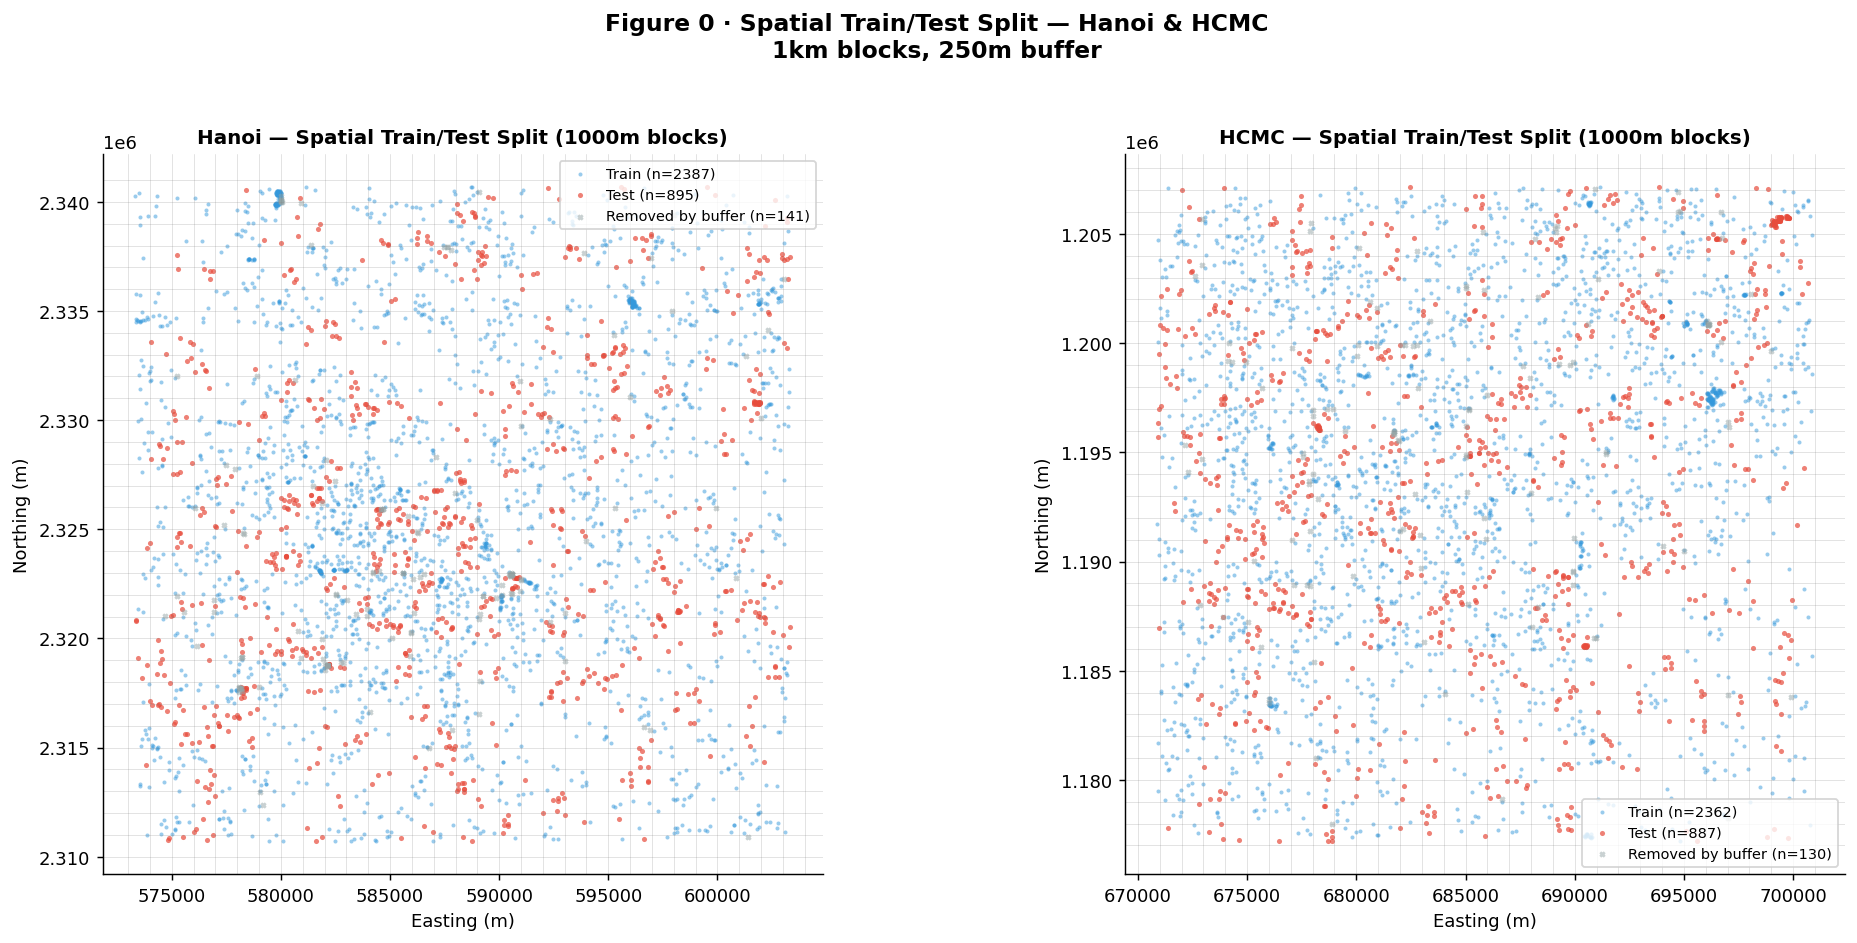

Figure 0 saved.


In [6]:
# Figure 0 -- Spatial train/test split per city
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (city_name, r) in zip(axes, city_results.items()):
    ct = r['coords_te']
    cr = r['coords_tr']
    # All test block points before buffer (reconstruct)
    smp_utm = city_results[city_name]['samples'].to_crs(CITIES[city_name]['utm_crs'])
    coords_all_c = np.column_stack([smp_utm.geometry.x, smp_utm.geometry.y])
    _, test_bm, keep = spatial_train_test_split(
        coords_all_c, 0.30, SPLIT_BLOCK_M, BUFFER_M, RANDOM_STATE)
    removed = coords_all_c[test_bm][~keep]

    ax.scatter(cr[:,0], cr[:,1], c='#3498db', s=5, alpha=0.5,
               linewidths=0, label=f'Train (n={len(cr)})')
    ax.scatter(ct[:,0], ct[:,1], c='#e74c3c', s=8, alpha=0.7,
               linewidths=0, label=f'Test (n={len(ct)})')
    if len(removed):
        ax.scatter(removed[:,0], removed[:,1], c='#95a5a6', s=6, alpha=0.5,
                   marker='x', label=f'Removed by buffer (n={len(removed)})')

    # Draw 1km grid
    x0, x1 = coords_all_c[:,0].min(), coords_all_c[:,0].max()
    y0, y1 = coords_all_c[:,1].min(), coords_all_c[:,1].max()
    for x in np.arange(x0//SPLIT_BLOCK_M*SPLIT_BLOCK_M, x1+SPLIT_BLOCK_M, SPLIT_BLOCK_M):
        ax.axvline(x, color='grey', lw=0.3, alpha=0.4)
    for y_v in np.arange(y0//SPLIT_BLOCK_M*SPLIT_BLOCK_M, y1+SPLIT_BLOCK_M, SPLIT_BLOCK_M):
        ax.axhline(y_v, color='grey', lw=0.3, alpha=0.4)

    ax.set_title(f'{city_name} — Spatial Train/Test Split ({SPLIT_BLOCK_M}m blocks)',
                 fontweight='bold')
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.set_aspect('equal'); ax.legend(fontsize=8)

fig.suptitle(f'Figure 0 · Spatial Train/Test Split — Hanoi & HCMC\n' +
             f'1km blocks, {BUFFER_M}m buffer',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig00_spatial_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 0 saved.')


---
## Cell 4 · Final comparison table — Milan vs Hanoi vs HCMC

In [ ]:
rows = [{
    'Scenario':  'Milan (baseline)',
    'City':      'Milan',
    'Approach':  'Train + test on CLMS (spatial split)',
    'RMSE':      round(milan_meta['holdout_rmse'], 2),
    'MAE':       round(milan_meta['holdout_mae'], 2),
    'R2':        round(milan_meta['holdout_r2'], 3),
    'Bias':      round(milan_meta['holdout_bias'], 2),
}]
for cn, r in city_results.items():
    rows.append({
        'Scenario': 'A - Milan model transfer',
        'City':     cn,
        'Approach': 'Milan model -> GHSL spatial test',
        'RMSE':     round(r['metrics_zs']['RMSE'], 2),
        'MAE':      round(r['metrics_zs']['MAE'], 2),
        'R2':       round(r['metrics_zs']['R2'], 3),
        'Bias':     round(r['metrics_zs']['Bias'], 2),
    })
    rows.append({
        'Scenario': 'B - Local retrain',
        'City':     cn,
        'Approach': f'GHSL spatial train -> spatial test (CV block={r["best_cv_block"]}m)',
        'RMSE':     round(r['metrics_lr']['RMSE'], 2),
        'MAE':      round(r['metrics_lr']['MAE'], 2),
        'R2':       round(r['metrics_lr']['R2'], 3),
        'Bias':     round(r['metrics_lr']['Bias'], 2),
    })
comp_df = pd.DataFrame(rows)
comp_df.to_csv(f'{OUTPUT_DIR}/transferability_comparison.csv', index=False)

print('='*70)
print('   TRANSFERABILITY COMPARISON')
print('='*70)
print(comp_df.to_string(index=False))
print('='*70)

# Also print best CV block per city
for cn, r in city_results.items():
    print(f'  {cn}: best spatial CV block = {r["best_cv_block"]}m  ' +
          f'(tune CV RMSE={r["cv_rmse_tune"]:.3f}%)')


---
## Cell 4b · Figure 1 — Metric bar chart

In [ ]:
# Figure 1 -- Bar chart of metrics
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'Bias']
ylabels         = ['RMSE (%)', 'MAE (%)', 'R2', 'Bias (%)']
scenario_colors = {
    'Milan (baseline)':         '#34495e',
    'A - Milan model transfer': '#e74c3c',
    'B - Local retrain':        '#27ae60',
}

for ax, metric, ylabel in zip(axes, metrics_to_plot, ylabels):
    bar_colors = [scenario_colors[s] for s in comp_df['Scenario']]
    labels = [f'{r["City"]}\n{r["Scenario"].split("-")[0].strip()}' for _, r in comp_df.iterrows()]
    bars = ax.bar(range(len(comp_df)), comp_df[metric],
                  color=bar_colors, edgecolor='white', linewidth=0.5)
    if metric == 'Bias':
        ax.axhline(0, color='black', lw=1, ls='--')
    for bar, val in zip(bars, comp_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(comp_df)))
    ax.set_xticklabels(labels, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel); ax.set_title(metric, fontweight='bold')

patches = [mpatches.Patch(color=col, label=sc) for sc, col in scenario_colors.items()]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig01_transfer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


---
## Cell 5 · Per-city scatter plots — Milan transfer vs local retrain

In [ ]:
# Figure -- Obs vs Pred scatter per city
for city_name, r in city_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, (label, y_pred, metrics) in zip(
        axes,
        [('Milan model transfer', r['y_pred_zs'], r['metrics_zs']),
         ('Local retrain',        r['y_pred_lr'], r['metrics_lr'])]
    ):
        for c in sorted(np.unique(r['cls_te'])):
            m = r['cls_te'] == c
            ax.scatter(r['y_te'][m], y_pred[m], c=CLASS_COLORS[c],
                       s=14, alpha=0.55, linewidths=0, label=CLASS_LABELS[c])
        ax.plot([0,100],[0,100],'k--',lw=1)
        ax.set_xlim(0,100); ax.set_ylim(0,100)
        ax.set_xlabel('Observed GHSL (%)'); ax.set_ylabel('Predicted IMD (%)')
        ax.set_title(label, fontweight='bold')
        ax.text(0.04, 0.93,
                f'RMSE={metrics["RMSE"]:.2f}\nMAE={metrics["MAE"]:.2f}\n' +
                f'R2={metrics["R2"]:.3f}\nBias={metrics["Bias"]:+.2f}',
                transform=ax.transAxes, fontsize=8.5,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='grey'))
    axes[0].legend(fontsize=6.5, framealpha=0.85, loc='lower right')
    fig.suptitle(f'Observed vs Predicted IMD -- {city_name}\n' +
                 f'(spatial test set | {SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer)',
                 fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_scatter_{city_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Scatter saved for {city_name}.')


---
## Cell 6 · Per-class metrics per city

In [ ]:
per_class_rows = []
for city_name, r in city_results.items():
    for scen_name, y_pred in [('Milan model transfer', r['y_pred_zs']),
                               ('Local', r['y_pred_lr'])]:
        for c in range(N_CLASSES):
            m = r['cls_te'] == c
            if m.sum() < 2:
                continue
            obs_c = r['y_te'][m]; pred_c = y_pred[m]
            per_class_rows.append({
                'City':     city_name,
                'Scenario': scen_name,
                'Class':    c,
                'N':        int(m.sum()),
                'RMSE':     round(float(np.sqrt(mean_squared_error(obs_c, pred_c))), 2),
                'MAE':      round(float(mean_absolute_error(obs_c, pred_c)), 2),
                'Bias':     round(float(np.mean(obs_c - pred_c)), 2),
            })
per_cls_df = pd.DataFrame(per_class_rows)
per_cls_df.to_csv(f'{OUTPUT_DIR}/per_class_metrics.csv', index=False)
print(per_cls_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, city_name in zip(axes, city_results.keys()):
    sub     = per_cls_df[per_cls_df['City'] == city_name]
    classes = sorted(sub['Class'].unique())
    x_pos   = np.array(classes, dtype=float)
    width   = 0.4
    zs_mae  = [sub[(sub['Class']==c)&(sub['Scenario']=='Milan model transfer')]['MAE'].values for c in classes]
    lr_mae  = [sub[(sub['Class']==c)&(sub['Scenario']=='Local')]['MAE'].values for c in classes]
    zs_mae  = [v[0] if len(v) else 0 for v in zs_mae]
    lr_mae  = [v[0] if len(v) else 0 for v in lr_mae]
    ax.bar(x_pos - width/2, zs_mae, width, color='#e74c3c', label='Milan model transfer', edgecolor='white')
    ax.bar(x_pos + width/2, lr_mae, width, color='#27ae60', label='Local retrain', edgecolor='white')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'C{c}' for c in classes])
    ax.set_xlabel('IMD Class'); ax.set_ylabel('MAE (%)')
    ax.set_title(f'{city_name} -- MAE per Class', fontweight='bold')
    ax.legend(fontsize=9)
fig.suptitle('Figure 2 · Per-Class MAE -- Milan model transfer vs Local Retrain\n' +
             f'(spatial test set | {SPLIT_BLOCK_M}m blocks, {BUFFER_M}m buffer)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig02_per_class_mae.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Cell 7 · GEE full-raster predictions and export

In [ ]:
# Milan RF params for GEE
milan_params = milan_meta['best_params']
print('Milan RF best params:', milan_params)

milan_train = gpd.read_file('./outputs_sampling/sample_points_train.gpkg').dropna().reset_index(drop=True)
milan_train['IMD_class'] = milan_train['IMD_class'].astype(int)

milan_features = []
for _, row in milan_train.iterrows():
    props = {b: float(row[b]) for b in band_names}
    props['IMD'] = float(row['IMD'])
    milan_features.append(ee.Feature(
        ee.Geometry.Point([row.geometry.x, row.geometry.y]), props))
milan_fc = ee.FeatureCollection(milan_features)

mf = milan_params.get('max_features', 'sqrt')
if mf in ['sqrt', "'sqrt'"]:
    vps_m = max(1, int(np.sqrt(len(band_names))))
elif mf in ['log2', "'log2'"]:
    vps_m = max(1, int(np.log2(len(band_names))))
else:
    try: vps_m = max(1, int(float(str(mf).strip("'")) * len(band_names)))
    except: vps_m = 8

milan_rf_gee = (
    ee.Classifier.smileRandomForest(
        numberOfTrees     = int(str(milan_params.get('n_estimators', 200)).strip("''")),
        variablesPerSplit = vps_m,
        minLeafPopulation = int(str(milan_params.get('min_samples_leaf', 2)).strip("''")),
        bagFraction       = 0.8,
        seed              = RANDOM_STATE
    )
    .setOutputMode('REGRESSION')
    .train(features=milan_fc, classProperty='IMD', inputProperties=band_names)
)
print('GEE Milan RF ready')

for city_name, r in city_results.items():
    print(f'\n-- {city_name} GEE predictions --')
    # Local RF trained on spatial training set
    smp = r['samples']
    local_features = []
    for _, row in smp.iterrows():
        props = {b: float(row[b]) for b in band_names}
        props['IMD'] = float(row['IMD'])
        local_features.append(ee.Feature(
            ee.Geometry.Point([row.geometry.x, row.geometry.y]), props))
    local_fc = ee.FeatureCollection(local_features)

    bp  = r['best_params']
    mf  = bp.get('max_features', 'sqrt')
    vps_l = max(1, int(np.sqrt(len(band_names)))) if mf == 'sqrt' else             max(1, int(np.log2(len(band_names)))) if mf == 'log2' else             max(1, int(float(mf) * len(band_names)))

    local_rf_gee = (
        ee.Classifier.smileRandomForest(
            numberOfTrees     = bp.get('n_estimators', 200),
            variablesPerSplit = vps_l,
            minLeafPopulation = bp.get('min_samples_leaf', 2),
            bagFraction       = float(bp.get('max_samples', 0.8) or 0.8),
            seed              = RANDOM_STATE
        )
        .setOutputMode('REGRESSION')
        .train(features=local_fc, classProperty='IMD', inputProperties=band_names)
    )

    pred_zs = r['aef_img'].classify(milan_rf_gee).rename('IMD_predicted').clamp(0, 100)
    pred_lr = r['aef_img'].classify(local_rf_gee).rename('IMD_predicted').clamp(0, 100)

    for tag, image in [('zeroshot', pred_zs), ('localrf', pred_lr)]:
        task = ee.batch.Export.image.toDrive(
            image=image,
            description=f'IMD_{city_name}_{tag}',
            folder='GEE_IMD_exports',
            fileNamePrefix=f'IMD_{city_name}_10m_{tag}',
            region=r['aoi_ee'], scale=10, crs=r['utm_crs'],
            maxPixels=1e10, fileFormat='GeoTIFF'
        )
        task.start()
        print(f'  Submitted: IMD_{city_name}_{tag}')

print('\nAll export tasks submitted.')
print('Monitor at: https://code.earthengine.google.com/tasks')


---
## Cell 8 · Save final outputs

In [ ]:
summary = {
    'milan_baseline': {
        'rmse': milan_meta['holdout_rmse'],
        'mae':  milan_meta['holdout_mae'],
        'r2':   milan_meta['holdout_r2'],
        'bias': milan_meta['holdout_bias'],
    }
}
for cn, r in city_results.items():
    summary[cn] = {
        'zero_shot':         r['metrics_zs'],
        'local_rf':          r['metrics_lr'],
        'best_cv_block_m':   r['best_cv_block'],
        'cv_rmse_tune':      r['cv_rmse_tune'],
        'n_samples_train':   len(r['train_idx']),
        'n_samples_test':    len(r['test_idx']),
        'buffer_removed':    int(r['block_mask_rem']),
    }
with open(f'{OUTPUT_DIR}/transfer_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('\n-- Final outputs --')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:<45} {size/1024:>8.1f} kB')

print('\n== FINAL SUMMARY ==')
print(f'  Milan baseline RMSE: {milan_meta["holdout_rmse"]:.2f}%')
for cn, r in city_results.items():
    print(f'  {cn} | Split: {len(r["train_idx"])} train / {len(r["test_idx"])} test ' +
          f'| CV block={r["best_cv_block"]}m')
    print(f'       Scenario A (Milan transfer): RMSE={r["metrics_zs"]["RMSE"]:.2f}%  R2={r["metrics_zs"]["R2"]:.3f}')
    print(f'       Scenario B (Local retrain):  RMSE={r["metrics_lr"]["RMSE"]:.2f}%  R2={r["metrics_lr"]["R2"]:.3f}')


---
## Cell 9 · Visualise predictions vs GHSL (after downloading GEE rasters)

In [ ]:
import matplotlib.ticker as mticker
import rasterio.enums

DISPLAY_SCALE = 5
imd_cmap = ListedColormap(IMD_PALETTE)
paths = {
    'Hanoi': {
        'ghsl': './data/IMD_2018_Hanoi.tif',
        'pred': './outputs_transfer_v2/IMD_Hanoi_10m_localrf.tif',
    },
    'HCMC': {
        'ghsl': './data/IMD_2018_HCMC.tif',
        'pred': './outputs_transfer_v2/IMD_HCMC_10m_localrf.tif',
    },
}

def imshow_aspect(ax, da, **kw):
    b  = da.rio.bounds()
    im = ax.imshow(da.values, extent=(b[0], b[2], b[1], b[3]), **kw)
    ax.set_aspect('equal')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
    ax.tick_params(axis='both', labelsize=8)
    ax.set_xlabel('Easting [m]', fontsize=9)
    ax.set_ylabel('Northing [m]', fontsize=9)
    return im

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          gridspec_kw={'wspace': 0.20, 'hspace': 0.25})

for row, city in enumerate(['Hanoi', 'HCMC']):
    pred      = rxr.open_rasterio(paths[city]['pred'], masked=True).squeeze('band', drop=True)
    ghsl      = rxr.open_rasterio(paths[city]['ghsl'], masked=True).squeeze('band', drop=True)
    if ghsl.rio.crs != pred.rio.crs:
        ghsl  = ghsl.rio.reproject(pred.rio.crs)
    ghsl_clip = ghsl.rio.clip_box(*pred.rio.bounds())

    water_path = f'./outputs_transfer_v2/water_mask_{city}.tif'
    water      = rxr.open_rasterio(water_path, masked=True).squeeze('band', drop=True)
    water      = water.rio.reproject_match(ghsl_clip, resampling=rasterio.enums.Resampling.nearest)
    water      = water.fillna(0)

    ghsl_masked = ghsl_clip.where(water == 0)
    pred_masked = pred.where(water.rio.reproject_match(pred, resampling=rasterio.enums.Resampling.nearest).fillna(0) == 0)

    im1 = imshow_aspect(axes[row, 0], ghsl_masked[::DISPLAY_SCALE, ::DISPLAY_SCALE], cmap=imd_cmap, vmin=0, vmax=100)
    axes[row, 0].set_title(f'{city} — GHSL Observed', fontweight='bold', fontsize=12)

    im2 = imshow_aspect(axes[row, 1], pred_masked[::DISPLAY_SCALE, ::DISPLAY_SCALE], cmap=imd_cmap, vmin=0, vmax=100)
    axes[row, 1].set_title(f'{city} — Predicted IMD (local RF)', fontweight='bold', fontsize=12)

fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.025, pad=0.04, label='IMD (%)')
fig.suptitle('IMD: Observed (GHSL) vs Predicted (RF + AEF) — Hanoi & HCMC',
             fontsize=14, fontweight='bold', y=0.94)
plt.savefig('./outputs_transfer_v2/fig_obs_vs_pred_hanoi_hcmc.png', dpi=150, bbox_inches='tight')
plt.show()